# Notebook 03 — Baseline Model (TF-IDF + Logistic Regression)
## AI-Powered Customer Feedback Intelligence System

**Purpose:** Establish a traditional ML performance baseline before fine-tuning DistilBERT.

**Pipeline:**
Review Text → TF-IDF Vectorizer → Logistic Regression → Sentiment Prediction

**Why this matters:**
- Gives us a benchmark to compare DistilBERT against
- Faster to train (seconds vs hours)
- Easier to interpret
- Strong interview talking point

**Expected output:**
- Trained baseline model saved to `models/baseline/`
- Accuracy, Precision, Recall, F1-score
- Confusion matrix
- Most predictive words for each sentiment

In [1]:
# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✅ Imports successful")

✅ Imports successful


In [2]:
# ============================================================
# LOAD PROCESSED DATA
# ============================================================

PROCESSED_PATH = os.path.join('..', 'data', 'processed')

df_train = pd.read_csv(os.path.join(PROCESSED_PATH, 'train.csv'))
df_val   = pd.read_csv(os.path.join(PROCESSED_PATH, 'val.csv'))
df_test  = pd.read_csv(os.path.join(PROCESSED_PATH, 'test.csv'))

print("✅ Data loaded successfully")
print(f"   Train : {len(df_train):,} rows")
print(f"   Val   : {len(df_val):,} rows")
print(f"   Test  : {len(df_test):,} rows")

# Extract text and labels
X_train = df_train['cleaned_text'].fillna('')
y_train = df_train['sentiment']

X_val   = df_val['cleaned_text'].fillna('')
y_val   = df_val['sentiment']

X_test  = df_test['cleaned_text'].fillna('')
y_test  = df_test['sentiment']

print(f"\nLabel distribution in train:")
print(f"   Positive (1): {(y_train==1).sum():,}")
print(f"   Negative (0): {(y_train==0).sum():,}")

✅ Data loaded successfully
   Train : 88,001 rows
   Val   : 10,999 rows
   Test  : 11,000 rows

Label distribution in train:
   Positive (1): 44,001
   Negative (0): 44,000


In [3]:
# ============================================================
# TF-IDF VECTORIZER
# ============================================================

# WHAT EACH PARAMETER MEANS:
#
# max_features=50000
#   Only keep the top 50,000 words by frequency.
#   Ignores very rare words that appear in < 5 reviews (likely typos).
#   Reduces memory and speeds up training.
#
# ngram_range=(1, 2)
#   (1,1) = single words only: "not", "good"
#   (1,2) = single words + pairs: "not good", "highly recommend"
#   Bigrams help capture negation — "not good" is very different from "good"
#   This directly addresses one of TF-IDF's biggest weaknesses.
#
# min_df=2
#   Ignore words that appear in fewer than 2 documents.
#   Removes typos and extremely rare tokens.
#
# sublinear_tf=True
#   Instead of raw term frequency, use log(1 + tf).
#   Prevents a word appearing 100 times from dominating a word appearing 10 times.
#   More balanced representation.

print("Building TF-IDF Vectorizer...")
print("Parameters:")
print("  max_features = 50,000")
print("  ngram_range  = (1, 2)  ← includes bigrams like 'not good'")
print("  min_df       = 2")
print("  sublinear_tf = True")

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

# IMPORTANT: Fit ONLY on training data.
# If we fit on val or test data, information from those sets
# leaks into our feature space — this is data leakage.
print("\nFitting vectorizer on TRAINING data only...")
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform val and test using the already-fitted vectorizer
print("Transforming validation data...")
X_val_tfidf   = tfidf.transform(X_val)

print("Transforming test data...")
X_test_tfidf  = tfidf.transform(X_test)

print(f"\n✅ TF-IDF complete")
print(f"   Vocabulary size      : {len(tfidf.vocabulary_):,} unique tokens")
print(f"   Train matrix shape   : {X_train_tfidf.shape}")
print(f"   Val matrix shape     : {X_val_tfidf.shape}")
print(f"   Test matrix shape    : {X_test_tfidf.shape}")
print(f"\n   Each review is now a vector of {X_train_tfidf.shape[1]:,} numbers.")
print(f"   Most values are 0 (sparse matrix) — only matched words have values.")

Building TF-IDF Vectorizer...
Parameters:
  max_features = 50,000
  ngram_range  = (1, 2)  ← includes bigrams like 'not good'
  min_df       = 2
  sublinear_tf = True

Fitting vectorizer on TRAINING data only...
Transforming validation data...
Transforming test data...

✅ TF-IDF complete
   Vocabulary size      : 50,000 unique tokens
   Train matrix shape   : (88001, 50000)
   Val matrix shape     : (10999, 50000)
   Test matrix shape    : (11000, 50000)

   Each review is now a vector of 50,000 numbers.
   Most values are 0 (sparse matrix) — only matched words have values.


In [4]:
# ============================================================
# TRAIN LOGISTIC REGRESSION
# ============================================================

# WHY LOGISTIC REGRESSION FOR BASELINE:
# - Fast to train (seconds on 88K samples)
# - Interpretable — we can see which words drive predictions
# - Surprisingly strong for text classification
# - Well understood, easy to explain in interviews
#
# KEY PARAMETERS:
#
# C=1.0
#   Regularization strength. Lower C = stronger regularization.
#   Prevents overfitting by penalizing very large coefficients.
#   C=1.0 is a sensible default for text classification.
#
# max_iter=1000
#   Maximum iterations for the solver to converge.
#   Text data with 50K features needs more iterations than default (100).
#
# solver='lbfgs'
#   Optimization algorithm. lbfgs works well for medium-sized datasets.

print("Training Logistic Regression...")
print("This should take 10-30 seconds on 88,000 samples...\n")

lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_SEED,
    verbose=1          # shows progress
)

lr_model.fit(X_train_tfidf, y_train)

print("\n✅ Logistic Regression training complete")

Training Logistic Regression...
This should take 10-30 seconds on 88,000 samples...


✅ Logistic Regression training complete


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished


In [6]:
# ============================================================
# EVALUATE ON VALIDATION SET
# ============================================================

# WHY VALIDATE BEFORE TESTING:
# We use the validation set to evaluate performance DURING development.
# The test set is only used ONCE at the very end.
# This prevents us from accidentally tuning our model to the test set.

y_val_pred = lr_model.predict(X_val_tfidf)

val_accuracy  = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall    = recall_score(y_val, y_val_pred)
val_f1        = f1_score(y_val, y_val_pred)

print("=" * 55)
print("BASELINE MODEL — VALIDATION SET RESULTS")
print("=" * 55)
print(f"  Accuracy  : {val_accuracy:.4f}  ({val_accuracy*100:.2f}%)")
print(f"  Precision : {val_precision:.4f}")
print(f"  Recall    : {val_recall:.4f}")
print(f"  F1-Score  : {val_f1:.4f}")
print("=" * 55)

print("\nWhat these metrics mean:")
print(f"  Accuracy  = out of all predictions, {val_accuracy*100:.1f}% were correct")
print(f"  Precision = when model says Positive, it's right {val_precision*100:.1f}% of the time")
print(f"  Recall    = model correctly finds {val_recall*100:.1f}% of all actual Positives")
print(f"  F1-Score  = harmonic mean of Precision and Recall")

print("\nFull Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Negative', 'Positive']))

BASELINE MODEL — VALIDATION SET RESULTS
  Accuracy  : 0.9212  (92.12%)
  Precision : 0.9257
  Recall    : 0.9158
  F1-Score  : 0.9207

What these metrics mean:
  Accuracy  = out of all predictions, 92.1% were correct
  Precision = when model says Positive, it's right 92.6% of the time
  Recall    = model correctly finds 91.6% of all actual Positives
  F1-Score  = harmonic mean of Precision and Recall

Full Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.93      0.92      5500
    Positive       0.93      0.92      0.92      5499

    accuracy                           0.92     10999
   macro avg       0.92      0.92      0.92     10999
weighted avg       0.92      0.92      0.92     10999



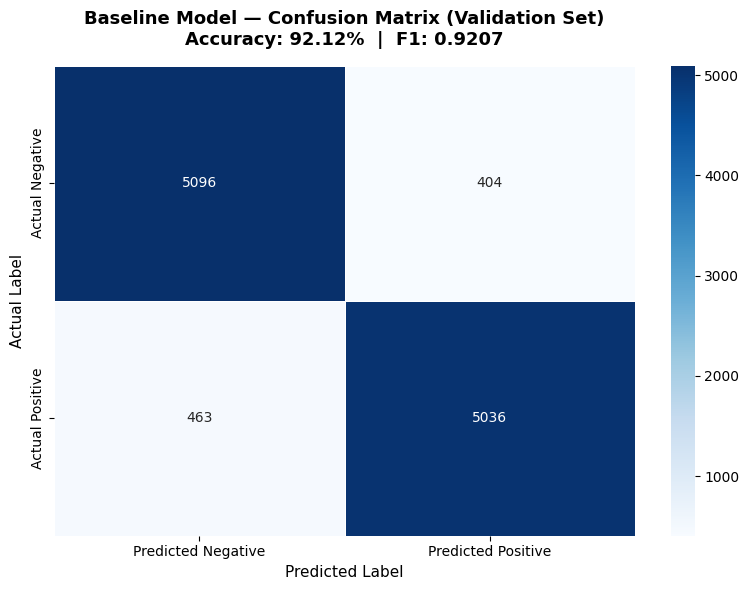

True Negatives  (correct negative predictions) : 5,096
False Positives (negative called positive)     : 404
False Negatives (positive called negative)     : 463
True Positives  (correct positive predictions) : 5,036


In [7]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

# WHAT A CONFUSION MATRIX SHOWS:
#
#                  Predicted Negative   Predicted Positive
# Actual Negative  [True Negative  ]    [False Positive  ]
# Actual Positive  [False Negative ]    [True Positive   ]
#
# False Positive = model said "Positive" but it was actually Negative
# False Negative = model said "Negative" but it was actually Positive
#
# For a business: False Negatives are dangerous.
# Missing a negative review means ignoring a real customer complaint.

cm = confusion_matrix(y_val, y_val_pred)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Negative', 'Predicted Positive'],
    yticklabels=['Actual Negative', 'Actual Positive'],
    linewidths=0.5,
    ax=ax
)

ax.set_title(
    f'Baseline Model — Confusion Matrix (Validation Set)\nAccuracy: {val_accuracy*100:.2f}%  |  F1: {val_f1:.4f}',
    fontsize=13,
    fontweight='bold',
    pad=15
)
ax.set_ylabel('Actual Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join('..', 'assets', 'baseline_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correct negative predictions) : {tn:,}")
print(f"False Positives (negative called positive)     : {fp:,}")
print(f"False Negatives (positive called negative)     : {fn:,}")
print(f"True Positives  (correct positive predictions) : {tp:,}")

TOP 20 WORDS PREDICTING POSITIVE SENTIMENT:
---------------------------------------------
  great                          +12.2153
  delicious                      +9.7840
  perfect                        +7.8330
  excellent                      +7.3739
  not too                        +7.2719
  good                           +7.2485
  wonderful                      +7.2086
  the best                       +6.9447
  best                           +6.6656
  amazing                        +6.3150
  love                           +6.1871
  nice                           +5.8333
  love this                      +5.6154
  loves                          +5.6120
  highly                         +5.3341
  awesome                        +5.1483
  love it                        +5.1227
  smooth                         +4.8831
  yummy                          +4.8809
  tasty                          +4.7949

TOP 20 WORDS PREDICTING NEGATIVE SENTIMENT:
--------------------------------------------

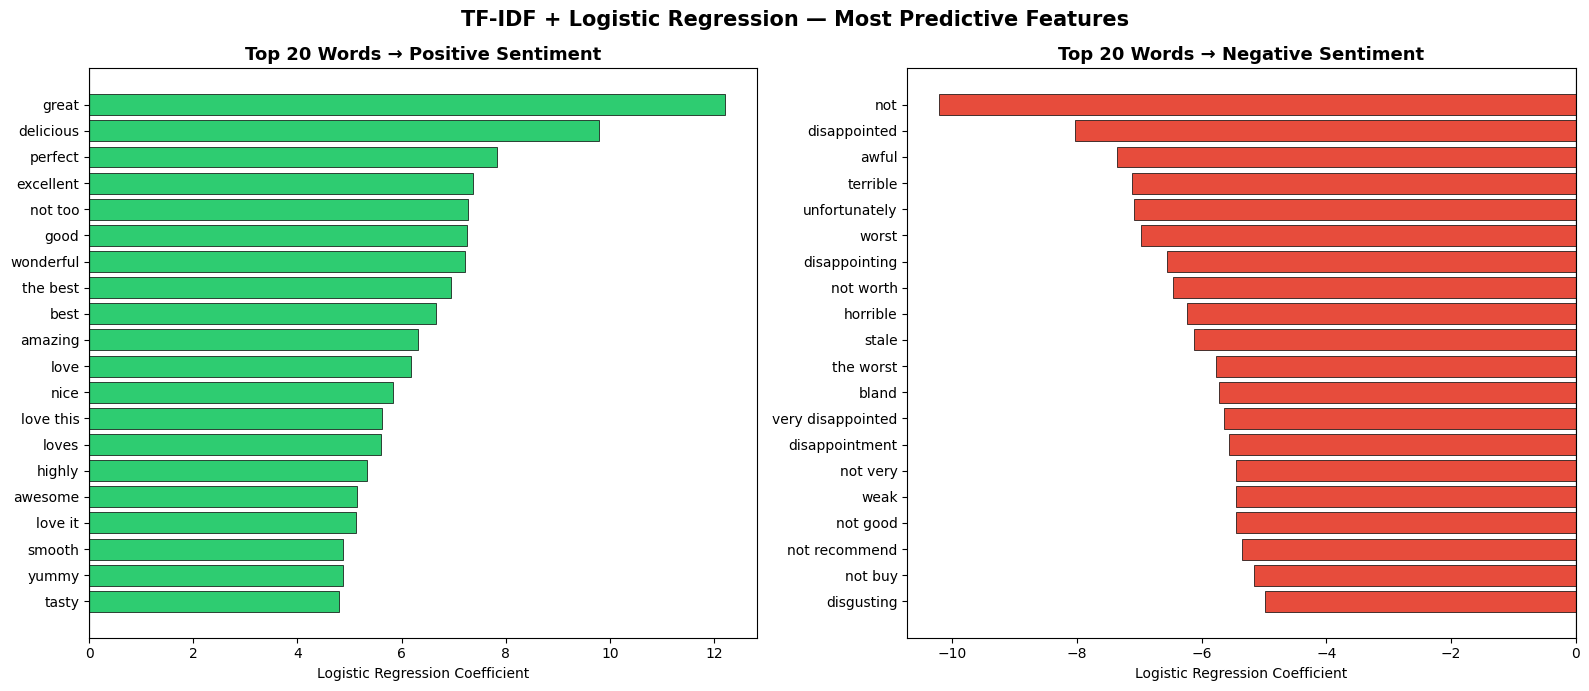

In [8]:
# ============================================================
# MOST PREDICTIVE WORDS — MODEL INTERPRETABILITY
# ============================================================

# This is one of the best features of Logistic Regression.
# We can directly inspect which words push the model
# toward Positive and which toward Negative.
# DistilBERT cannot give us this level of interpretability easily.

feature_names = tfidf.get_feature_names_out()
coefficients  = lr_model.coef_[0]

TOP_N = 20

# Most positive words (highest positive coefficients)
top_positive_idx   = np.argsort(coefficients)[-TOP_N:][::-1]
top_positive_words = [(feature_names[i], coefficients[i]) for i in top_positive_idx]

# Most negative words (most negative coefficients)
top_negative_idx   = np.argsort(coefficients)[:TOP_N]
top_negative_words = [(feature_names[i], coefficients[i]) for i in top_negative_idx]

print("TOP 20 WORDS PREDICTING POSITIVE SENTIMENT:")
print("-" * 45)
for word, coef in top_positive_words:
    print(f"  {word:<30} {coef:+.4f}")

print("\nTOP 20 WORDS PREDICTING NEGATIVE SENTIMENT:")
print("-" * 45)
for word, coef in top_negative_words:
    print(f"  {word:<30} {coef:+.4f}")

# ── Visualization ──
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Positive words
pos_words = [w for w, _ in top_positive_words]
pos_coefs = [c for _, c in top_positive_words]
axes[0].barh(pos_words[::-1], pos_coefs[::-1], color='#2ecc71', edgecolor='black', linewidth=0.5)
axes[0].set_title('Top 20 Words → Positive Sentiment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Logistic Regression Coefficient')
axes[0].axvline(x=0, color='black', linewidth=0.8)

# Negative words
neg_words = [w for w, _ in top_negative_words]
neg_coefs = [c for _, c in top_negative_words]
axes[1].barh(neg_words[::-1], neg_coefs[::-1], color='#e74c3c', edgecolor='black', linewidth=0.5)
axes[1].set_title('Top 20 Words → Negative Sentiment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Logistic Regression Coefficient')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.suptitle('TF-IDF + Logistic Regression — Most Predictive Features',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'assets', 'baseline_top_features.png'), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ============================================================
# SAVE BASELINE MODEL
# ============================================================

# We save both the vectorizer AND the model.
# At inference time we need BOTH:
#   1. TF-IDF vectorizer — to convert new text to numbers
#   2. Logistic Regression — to classify those numbers

BASELINE_PATH = os.path.join('..', 'models', 'baseline')
os.makedirs(BASELINE_PATH, exist_ok=True)

tfidf_path = os.path.join(BASELINE_PATH, 'tfidf_vectorizer.joblib')
model_path = os.path.join(BASELINE_PATH, 'logistic_regression.joblib')

joblib.dump(tfidf, tfidf_path)
joblib.dump(lr_model, model_path)

print("✅ Baseline model saved")
print(f"   TF-IDF vectorizer  → {tfidf_path}")
print(f"   Logistic Regression → {model_path}")

# Save validation metrics to a text file for comparison later
metrics_path = os.path.join(BASELINE_PATH, 'validation_metrics.txt')
with open(metrics_path, 'w') as f:
    f.write("BASELINE MODEL — VALIDATION METRICS\n")
    f.write("=" * 40 + "\n")
    f.write(f"Accuracy  : {val_accuracy:.4f}\n")
    f.write(f"Precision : {val_precision:.4f}\n")
    f.write(f"Recall    : {val_recall:.4f}\n")
    f.write(f"F1-Score  : {val_f1:.4f}\n")
    f.write("\nClassification Report:\n")
    f.write(classification_report(y_val, y_val_pred, target_names=['Negative', 'Positive']))

print(f"   Metrics saved      → {metrics_path}")

print(f"""
╔══════════════════════════════════════════════════════╗
║         PHASE 5 COMPLETE ✅                         ║
╠══════════════════════════════════════════════════════╣
║  Baseline model trained and saved                   ║
║  TF-IDF vocabulary: ~50,000 tokens                  ║
║  Validation metrics recorded                        ║
║                                                      ║
║  NEXT: Notebook 04 — DistilBERT Fine-tuning         ║
╚══════════════════════════════════════════════════════╝
""")

✅ Baseline model saved
   TF-IDF vectorizer  → ..\models\baseline\tfidf_vectorizer.joblib
   Logistic Regression → ..\models\baseline\logistic_regression.joblib
   Metrics saved      → ..\models\baseline\validation_metrics.txt

╔══════════════════════════════════════════════════════╗
║         PHASE 5 COMPLETE ✅                         ║
╠══════════════════════════════════════════════════════╣
║  Baseline model trained and saved                   ║
║  TF-IDF vocabulary: ~50,000 tokens                  ║
║  Validation metrics recorded                        ║
║                                                      ║
║  NEXT: Notebook 04 — DistilBERT Fine-tuning         ║
╚══════════════════════════════════════════════════════╝

